### Understand the Problem

### Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

### Data Exploration

In [2]:
dataset_train=pd.read_csv("/kaggle/input/home-data-for-ml-course/train.csv")
dataset_train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [3]:
dataset_test=pd.read_csv("/kaggle/input/home-data-for-ml-course/test.csv")
dataset_test.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal


In [4]:
dataset_train.shape

(1460, 81)

In [5]:
dataset_test.shape

(1459, 80)

In [6]:
dataset_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
dataset_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [8]:
dataset_train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [9]:
dataset_test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

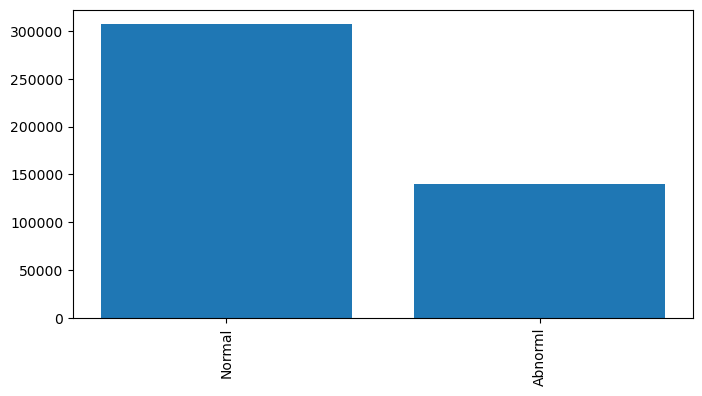

In [10]:
name = dataset_train['SaleCondition']
price = dataset_train['SalePrice']
 
# Figure Size
fig = plt.figure(figsize =(8, 4))
 
# Horizontal Bar Plot
plt.bar(name[0:10], price[0:10])

plt.xticks(rotation=90) #To rotate x axis names

# Show Plot
plt.show()

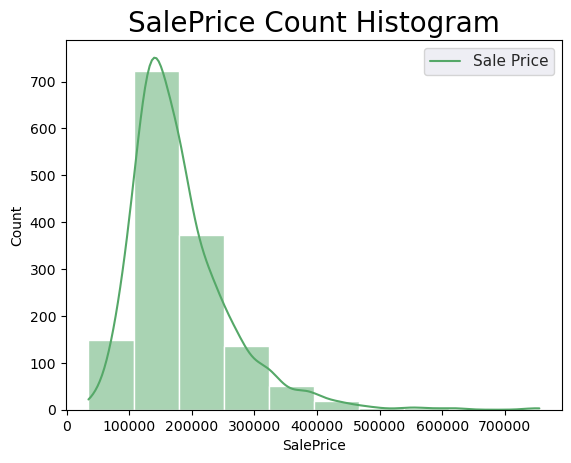

In [11]:
#set figure
f, ax = plt.subplots(1,1)

#graph histogram
sns.set(style='darkgrid')
sns.histplot(data = dataset_train, x = "SalePrice", color='g', bins=10, kde = True, legend=False)

#Set title
ax.set_title("SalePrice Count Histogram",  fontsize=20)
# plt.ylim(0, 100)
#set legend
plt.legend(loc='upper right', labels=['Sale Price'])

### Fill the null value

In [12]:
df_train=dataset_train.fillna(method="ffill")#fill the null values

In [13]:
df_test=dataset_test.fillna(method="ffill")#fill the null values

In [14]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [15]:
df_test.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### Label Encoding on multiple columns

In [16]:
from sklearn import preprocessing
columns = df_train[['MSZoning', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
        'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
        'Functional', 'FireplaceQu', 'GarageType',
        'GarageFinish',  'GarageQual',
       'GarageCond', 'PavedDrive',  'PoolQC',
       'Fence', 'MiscFeature',  'SaleType',
       'SaleCondition']]  # columns names where transform is required
for X in columns:
  exec(f'le_{X} = preprocessing.LabelEncoder()')  #create label encoder with name "le_X", where X is column name
  exec(f'df_train.{X} = le_{X}.fit_transform(df_train.{X})')  #execute fit transform for column X with respective lable encoder "le_X", where X is column name
df_train.head() 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,2,3,3,0,...,0,3,4,4,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,2,3,3,0,...,0,3,4,4,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,2,0,3,0,...,0,3,4,4,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,2,0,3,0,...,0,3,4,4,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,2,0,3,0,...,0,3,4,4,0,12,2008,8,4,250000


In [17]:
from sklearn import preprocessing
columns = df_test[['MSZoning', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
        'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
        'Functional', 'FireplaceQu', 'GarageType',
        'GarageFinish',  'GarageQual',
       'GarageCond', 'PavedDrive',  'PoolQC',
       'Fence', 'MiscFeature',  'SaleType',
       'SaleCondition']]  # columns names where transform is required
for X in columns:
  exec(f'le_{X} = preprocessing.LabelEncoder()')  #create label encoder with name "le_X", where X is column name
  exec(f'df_test.{X} = le_{X}.fit_transform(df_test.{X})')  #execute fit transform for column X with respective lable encoder "le_X", where X is column name
df_test.head() 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,2,80.0,11622,1,2,3,3,0,...,120,0,2,2,3,0,6,2010,8,4
1,1462,20,3,81.0,14267,1,2,0,3,0,...,0,0,2,2,0,12500,6,2010,8,4
2,1463,60,3,74.0,13830,1,2,0,3,0,...,0,0,2,2,0,0,3,2010,8,4
3,1464,60,3,78.0,9978,1,2,0,3,0,...,0,0,2,2,0,0,6,2010,8,4
4,1465,120,3,43.0,5005,1,2,0,1,0,...,144,0,2,2,0,0,1,2010,8,4


In [18]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   int64  
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   int64  
 6   Alley          1460 non-null   int64  
 7   LotShape       1460 non-null   int64  
 8   LandContour    1460 non-null   int64  
 9   Utilities      1460 non-null   int64  
 10  LotConfig      1460 non-null   int64  
 11  LandSlope      1460 non-null   int64  
 12  Neighborhood   1460 non-null   int64  
 13  Condition1     1460 non-null   int64  
 14  Condition2     1460 non-null   int64  
 15  BldgType       1460 non-null   int64  
 16  HouseStyle     1460 non-null   int64  
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [19]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   int64  
 3   LotFrontage    1459 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   int64  
 6   Alley          1459 non-null   int64  
 7   LotShape       1459 non-null   int64  
 8   LandContour    1459 non-null   int64  
 9   Utilities      1459 non-null   int64  
 10  LotConfig      1459 non-null   int64  
 11  LandSlope      1459 non-null   int64  
 12  Neighborhood   1459 non-null   int64  
 13  Condition1     1459 non-null   int64  
 14  Condition2     1459 non-null   int64  
 15  BldgType       1459 non-null   int64  
 16  HouseStyle     1459 non-null   int64  
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [20]:
x=df_train[['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC',
       'Fence', 'MiscFeature', 'MiscVal', 'MoSold', 'YrSold', 'SaleType',
       'SaleCondition']]
y=df_train[['SalePrice']]

In [21]:
x

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,3,65.0,8450,1,2,3,3,0,...,0,0,3,4,4,0,2,2008,8,4
1,2,20,3,80.0,9600,1,2,3,3,0,...,0,0,3,4,4,0,5,2007,8,4
2,3,60,3,68.0,11250,1,2,0,3,0,...,0,0,3,4,4,0,9,2008,8,4
3,4,70,3,60.0,9550,1,2,0,3,0,...,0,0,3,4,4,0,2,2006,8,0
4,5,60,3,84.0,14260,1,2,0,3,0,...,0,0,3,4,4,0,12,2008,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3,62.0,7917,1,1,3,3,0,...,0,0,2,1,3,0,8,2007,8,4
1456,1457,20,3,85.0,13175,1,1,3,3,0,...,0,0,2,2,3,0,2,2010,8,4
1457,1458,70,3,66.0,9042,1,1,3,3,0,...,0,0,2,0,2,2500,5,2010,8,4
1458,1459,20,3,68.0,9717,1,1,3,3,0,...,0,0,2,0,2,0,4,2010,8,4


In [22]:
y

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


### Split the dataset using hold out validation approch

In this split, sometimes underfitting and overfitting problems have occured

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=50)

In [24]:
x_train.shape

(1022, 80)

In [25]:
y_train.shape

(1022, 1)

In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model=model.fit(x_train,y_train)

In [27]:
model.score(x_test,y_test)*100 #accuracy

80.71751266184644

In [28]:
sample= model.predict(x_test)
print(sample)

[[240590.99294063]
 [196925.3907574 ]
 [118469.17337705]
 [122956.09592124]
 [296597.09012151]
 [173498.1250346 ]
 [149306.86849894]
 [147217.40131162]
 [139089.63318659]
 [209105.13627435]
 [121044.98519603]
 [197978.13461512]
 [ 28024.47910944]
 [183743.66988563]
 [215485.60528876]
 [230893.06720615]
 [128176.85234776]
 [175989.82410312]
 [342260.18873112]
 [125183.66722513]
 [263773.74554927]
 [378194.97715859]
 [130832.20888515]
 [195130.012727  ]
 [159363.20801917]
 [218775.72112137]
 [258287.21532128]
 [102353.34882253]
 [323861.14124805]
 [269270.73444418]
 [125928.09005636]
 [124467.88552742]
 [215943.30458788]
 [127584.94750345]
 [ 88800.9598585 ]
 [146014.44909295]
 [175471.93166024]
 [206198.52031502]
 [ 92942.06731135]
 [101983.71017616]
 [110890.15184326]
 [219754.29747878]
 [191455.19638473]
 [237357.07706754]
 [128870.0268718 ]
 [354564.57593565]
 [161147.94955671]
 [190459.10211048]
 [197454.0394962 ]
 [214057.65246186]
 [244711.77101981]
 [236183.91542428]
 [189356.357

In [29]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
error = mean_absolute_error(sample,y_test)*100
error#error

2098886.336509407

### Kfold cross validation

In [30]:
from sklearn.model_selection import KFold

#model=LinearRegression()
kfold_validation=KFold(10)#basically KFold(10) represents we have to do 10 different splits

In [31]:
import numpy as np
from sklearn.model_selection import cross_val_score
result=cross_val_score(model,x,y,cv=kfold_validation)
print(result)
print("Accuracy : ",np.mean(result))
#10 different model shows 10 different accuracy and then show the mean accuracy

[0.88900666 0.87973894 0.8959317  0.74205439 0.85599364 0.85708386
 0.84346987 0.85152145 0.52288747 0.87797206]
Accuracy :  0.8215660034937569


### Stratified kfold cross validation

This cross validation is particularly used on unevened dataset and classification data
e.g. diabetes yes->700 no->300
in certain case, this cross validation we could use

### Leave One Out Cross Validation(LOOCV)

In this LOOCV,only one raw has taken as test and every single data will be gone to train.
this is the slowest method.



If we have dataset in million we should not use that.

In [32]:
#from sklearn.model_selection import LeaveOneOut
#leave_validation=LeaveOneOut()
#results=cross_val_score(model,x,y,cv=leave_validation)
#results

### Repeated random test-turn splits

This is hybrid of hold-out cross validation(traditional train test split) and k-fold cross validation method.In this technique, we create random splits of the data in the training-test set manner and then repeat the process of splitting and evaluting teh algorithm multiple times, just like cross validation

In [33]:
from sklearn.model_selection import ShuffleSplit 
ssplit=ShuffleSplit(n_splits=10,test_size=0.30)
results=cross_val_score(model,x,y,cv=ssplit)

In [34]:
results

array([0.84555118, 0.72751117, 0.76630955, 0.82585949, 0.79153926,
       0.80007991, 0.72847695, 0.85725747, 0.78487333, 0.84046207])

In [35]:
np.mean(results)

0.7967920391597513

In [36]:
r=model.predict(df_test)
r

array([[ 89304.53786907],
       [122841.21882238],
       [161595.57430182],
       ...,
       [138151.52992372],
       [110663.45657404],
       [235219.88438887]])

In [37]:
df_price = pd.DataFrame(r, columns =['SalePrice'])
df_price


,SalePrice
0,89304.537869
1,122841.218822
2,161595.574302
3,170227.359883
4,184721.981096
...,...
1454,63495.923617
1455,58787.466594
1456,138151.529924
1457,110663.456574


In [38]:
test1=pd.read_csv("/kaggle/input/home-data-for-ml-course/test.csv")
test1.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [39]:
test2=test1["Id"]
res = np.array(test2)
res

array([1461, 1462, 1463, ..., 2917, 2918, 2919])

In [40]:
df_price2 = pd.DataFrame(res, columns =['Id'])
df_price2


,Id
0,1461
1,1462
2,1463
3,1464
4,1465
...,...
1454,2915
1455,2916
1456,2917
1457,2918


In [41]:
result = pd.concat([df_price2,df_price], axis=1, join='inner')
display(result)

,Id,SalePrice
0,1461,89304.537869
1,1462,122841.218822
2,1463,161595.574302
3,1464,170227.359883
4,1465,184721.981096
...,...,...
1454,2915,63495.923617
1455,2916,58787.466594
1456,2917,138151.529924
1457,2918,110663.456574


In [42]:
result.set_index("Id", inplace=True)
result.to_csv("sample_submission2.csv")

In [43]:
pd.read_csv("sample_submission2.csv")

,Id,SalePrice
0,1461,89304.537869
1,1462,122841.218822
2,1463,161595.574302
3,1464,170227.359883
4,1465,184721.981096
...,...,...
1454,2915,63495.923617
1455,2916,58787.466594
1456,2917,138151.529924
1457,2918,110663.456574
